<a href="https://colab.research.google.com/github/mohadesehsotoudehnia/AI-home-works/blob/main/miniProject3%20/%20MP3_part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Question 6**

# **Defining Membership Functions for Inputs and Outputs**

In [ ]:
# install scikit-fuzzy for fuzzy logic
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# define fuzzy input: distance
distance = ctrl.Antecedent(np.arange(0, 3.5, 0.1), 'distance')

# define fuzzy input: angle_error
angle_error = ctrl.Antecedent(np.arange(-np.pi, np.pi, 0.1), 'angle_error')

In [ ]:
# define fuzzy output: linear speed v
v = ctrl.Consequent(np.arange(0, 0.6, 0.05), 'v')

# define fuzzy output: angular speed omega
omega = ctrl.Consequent(np.arange(-1, 1.1, 0.1), 'omega')

In [ ]:
# membership functions for distance
distance['S'] = fuzz.trimf(distance.universe, [0, 0, 1])
distance['M'] = fuzz.trimf(distance.universe, [0.5, 1.5, 2.5])
distance['L'] = fuzz.trimf(distance.universe, [1.5, 3, 3])

# membership functions for angle_error
angle_error['N'] = fuzz.trimf(angle_error.universe, [-np.pi, -np.pi/2, 0])
angle_error['Z'] = fuzz.trimf(angle_error.universe, [-0.5, 0, 0.5])
angle_error['P'] = fuzz.trimf(angle_error.universe, [0, np.pi/2, np.pi])

In [ ]:
# membership functions for v
v['low'] = fuzz.trimf(v.universe, [0, 0, 0.2])
v['medium'] = fuzz.trimf(v.universe, [0.1, 0.3, 0.5])
v['high'] = fuzz.trimf(v.universe, [0.3, 0.5, 0.5])

# membership functions for omega
omega['neg'] = fuzz.trimf(omega.universe, [-1, -1, 0])
omega['zero'] = fuzz.trimf(omega.universe, [-0.1, 0, 0.1])
omega['pos'] = fuzz.trimf(omega.universe, [0, 1, 1])

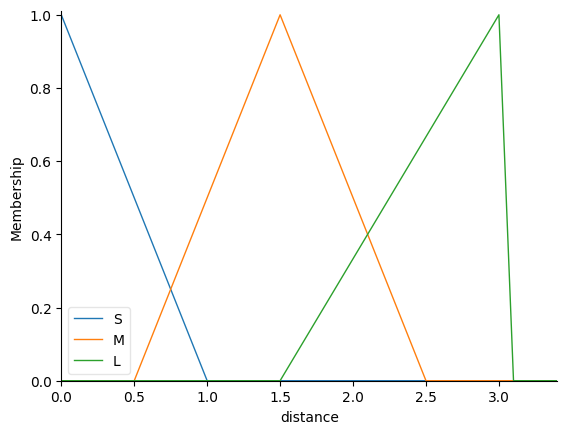

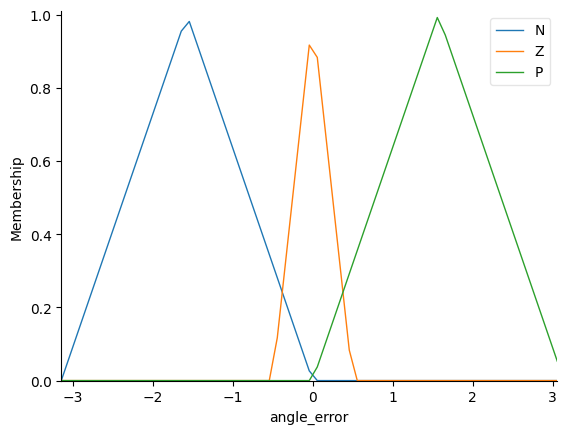

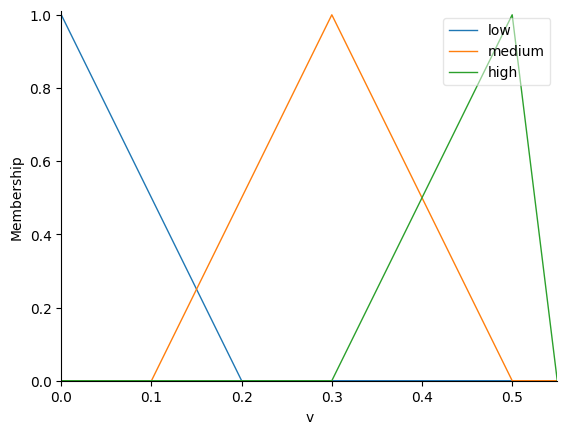

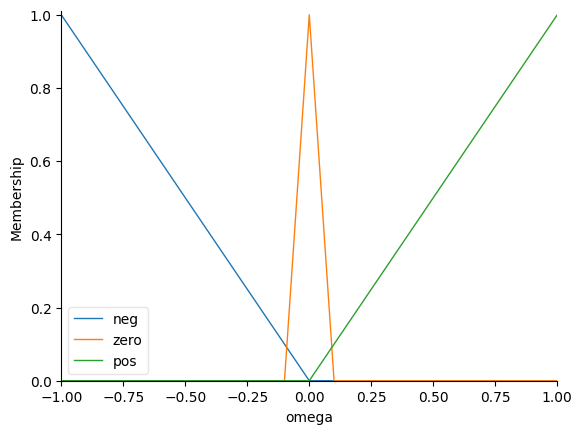

In [ ]:
import matplotlib.pyplot as plt

# plot membership functions for distance
distance.view()
plt.show()

# plot membership functions for angle_error
angle_error.view()
plt.show()

# plot membership functions for v
v.view()
plt.show()

# plot membership functions for omega
omega.view()
plt.show()

# **Set Fuzzy Rules**

/tmp/ipython-input-7-1986961681.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['', 'Negative', 'Zero', 'Positive'])
/tmp/ipython-input-7-1986961681.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['', 'Small', 'Medium', 'Large'])


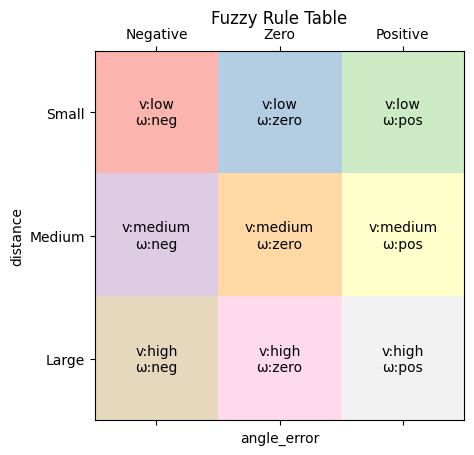

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define output labels for v and omega based on distance and angle_error
labels_v = [['low', 'low', 'low'],
            ['medium', 'medium', 'medium'],
            ['high', 'high', 'high']]

labels_w = [['neg', 'zero', 'pos'],
            ['neg', 'zero', 'pos'],
            ['neg', 'zero', 'pos']]

# Create a dummy matrix for plotting
data = np.arange(9).reshape(3, 3)

# Plot the rule table as a heatmap
fig, ax = plt.subplots()
cax = ax.matshow(data, cmap='Pastel1')

# Set axis labels
ax.set_xticklabels(['', 'Negative', 'Zero', 'Positive'])
ax.set_yticklabels(['', 'Small', 'Medium', 'Large'])

# Write v and omega labels inside each cell
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'v:{labels_v[i][j]}\nω:{labels_w[i][j]}',
                ha='center', va='center', fontsize=10)

plt.title("Fuzzy Rule Table", pad=20)
plt.xlabel("angle_error")
plt.ylabel("distance")
plt.show()


In [ ]:
# Define fuzzy rules based on the rule table

rule1 = ctrl.Rule(distance['S'] & angle_error['N'], (v['low'], omega['neg']))
rule2 = ctrl.Rule(distance['S'] & angle_error['Z'], (v['low'], omega['zero']))
rule3 = ctrl.Rule(distance['S'] & angle_error['P'], (v['low'], omega['pos']))

rule4 = ctrl.Rule(distance['M'] & angle_error['N'], (v['medium'], omega['neg']))
rule5 = ctrl.Rule(distance['M'] & angle_error['Z'], (v['medium'], omega['zero']))
rule6 = ctrl.Rule(distance['M'] & angle_error['P'], (v['medium'], omega['pos']))

rule7 = ctrl.Rule(distance['L'] & angle_error['N'], (v['high'], omega['neg']))
rule8 = ctrl.Rule(distance['L'] & angle_error['Z'], (v['high'], omega['zero']))
rule9 = ctrl.Rule(distance['L'] & angle_error['P'], (v['high'], omega['pos']))



In [ ]:
# Create fuzzy control system from all 9 rules
control_system = ctrl.ControlSystem([
    rule1, rule2, rule3,
    rule4, rule5, rule6,
    rule7, rule8, rule9
])

In [ ]:
# Create simulation object to evaluate inputs and get outputs
sim = ctrl.ControlSystemSimulation(control_system)


In [ ]:
# Define a list of test cases (each with distance and angle_error)
test_inputs = [
    {"distance": 0.5, "angle_error": -1.0},
    {"distance": 1.5, "angle_error": 0.0},
    {"distance": 3.0, "angle_error": 0.7},
    {"distance": 2.5, "angle_error": -0.5},
    {"distance": 1.0, "angle_error": 1.0}
]


In [ ]:
# Run all tests and print v and omega outputs
for i, inputs in enumerate(test_inputs):
    sim.input['distance'] = inputs['distance']
    sim.input['angle_error'] = inputs['angle_error']
    sim.compute()

    print(f"Test {i+1}:")
    print(f"Input → distance = {inputs['distance']:.2f}, angle_error = {inputs['angle_error']:.2f}")
    print(f"Output → v = {sim.output['v']:.3f}, omega = {sim.output['omega']:.3f}")
    print("-" * 35)


Test 1:
Input → distance = 0.50, angle_error = -1.00
Output → v = 0.078, omega = -0.611
-----------------------------------
Test 2:
Input → distance = 1.50, angle_error = 0.00
Output → v = 0.300, omega = -0.000
-----------------------------------
Test 3:
Input → distance = 3.00, angle_error = 0.70
Output → v = 0.440, omega = 0.601
-----------------------------------
Test 4:
Input → distance = 2.50, angle_error = -0.50
Output → v = 0.436, omega = -0.559
-----------------------------------
Test 5:
Input → distance = 1.00, angle_error = 1.00
Output → v = 0.300, omega = 0.611
-----------------------------------


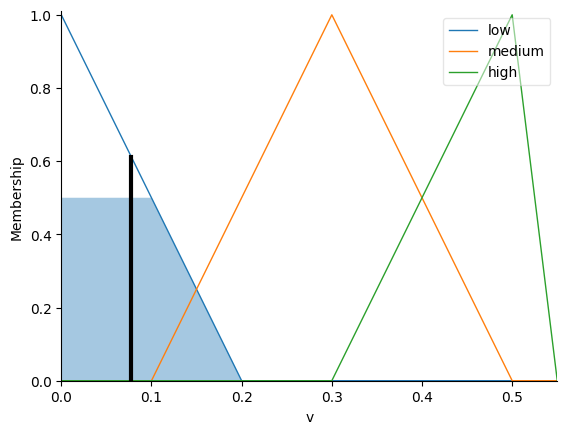

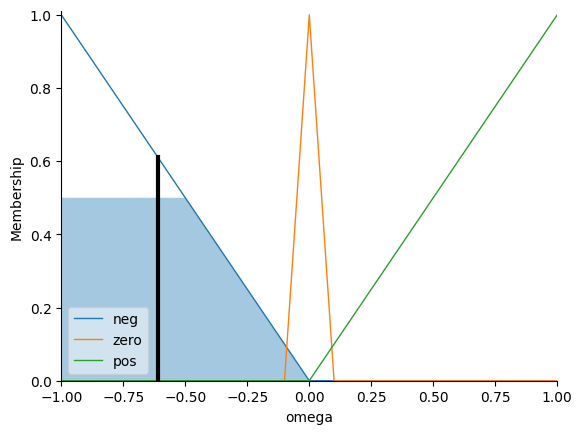

In [ ]:
# Set test 1 inputs
sim.input['distance'] = 0.5
sim.input['angle_error'] = -1.0
sim.compute()

# Plot output memberships
v.view(sim)
omega.view(sim)


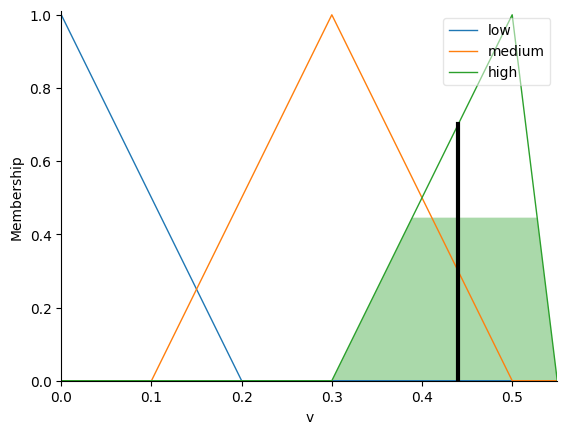

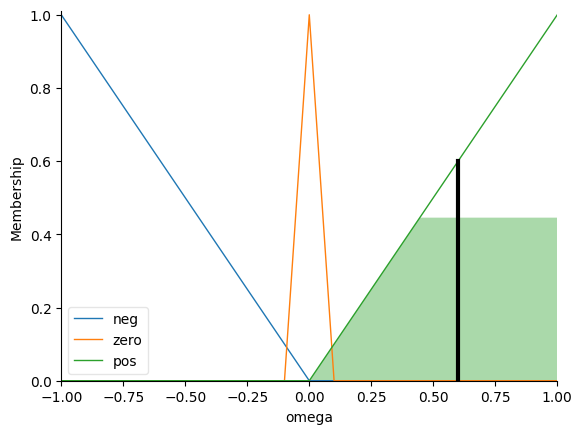

In [ ]:
# Set test 3 inputs
sim.input['distance'] = 3.0
sim.input['angle_error'] = 0.7
sim.compute()

# Plot output memberships
v.view(sim)
omega.view(sim)

# **Simulation Loop**

In [ ]:
import numpy as np

# Initial state of the robot
x, y, theta = 0.0, 0.0, 0.0

# Target state (from question)
x_goal, y_goal = 2.0, 2.0
theta_goal = np.pi / 2

# Time step and simulation limits
dt = 0.1
max_steps = 300

# Store robot trajectory
x_path = [x]
y_path = [y]
theta_path = [theta]


In [ ]:
# Simulate robot motion from initial to goal position
for step in range(max_steps):

    # Compute goal distance and angle error
    dx = x_goal - x
    dy = y_goal - y
    distance_to_goal = np.hypot(dx, dy)
    angle_to_goal = np.arctan2(dy, dx)
    angle_error = (angle_to_goal - theta + np.pi) % (2 * np.pi) - np.pi

    # Set fuzzy inputs and compute outputs
    sim.input['distance'] = distance_to_goal
    sim.input['angle_error'] = angle_error
    sim.compute()
    v_output = np.clip(sim.output['v'], 0.0, 0.5)
    omega_output = np.clip(sim.output['omega'], -1.0, 1.0)

    # Update robot position and orientation
    x += v_output * np.cos(theta) * dt
    y += v_output * np.sin(theta) * dt
    theta += omega_output * dt

    # Store robot path
    x_path.append(x)
    y_path.append(y)
    theta_path.append(theta)

    # Stop condition
    theta_error = (theta - theta_goal + np.pi) % (2 * np.pi) - np.pi
    if distance_to_goal < 0.1 and abs(theta_error) < 0.1 and step > 10:
        break


# **Plot Robot Path**

In [ ]:
import matplotlib.pyplot as plt

# Set figure size and basic plot setup
plt.figure(figsize=(6, 6))


<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

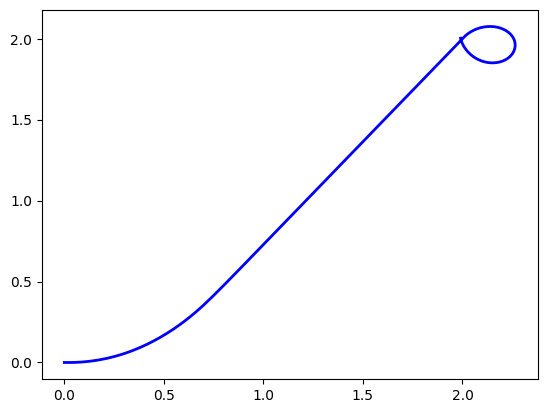

In [ ]:
# Plot robot path
plt.plot(x_path, y_path, label='Robot Path', color='blue', linewidth=2)


# **Question7**

# **Data Preparation**

In [ ]:
!pip install gdown

import gdown

file_id = "1sn9kDXA0E4rLx1rZOX99z62flVMf_YEO"

url = f"https://drive.google.com/uc?id={file_id}"

output = "diabetes.csv"


gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1sn9kDXA0E4rLx1rZOX99z62flVMf_YEO
To: /content/diabetes.csv
100%|██████████| 23.9k/23.9k [00:00<00:00, 26.2MB/s]


'diabetes.csv'

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('diabetes.csv')

# Show first few rows
print(df.head())

# List of columns where zero is invalid
cols_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace zero values with NaN in those columns
df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, pd.NA)

# Show how many missing values exist now
print("Missing values per column:")
print(df.isna().sum())

# Drop rows with any missing values
df_cleaned = df.dropna()

# Show shape of cleaned data
print("Cleaned dataset shape:", df_cleaned.shape)

# Optional: Reset index
df_cleaned = df_cleaned.reset_index(drop=True)


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Missing values per column:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome             

# **Define Fuzzy Membership Functions**

In [ ]:
# Install fuzzy logic library (scikit-fuzzy)
# Only needs to be run once in Google Colab
!pip install scikit-fuzzy


In [ ]:
# Select features for ANFIS model
selected_columns = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Outcome']
data = df_cleaned[selected_columns]

# Split into inputs (X) and output (Y)
X = data.iloc[:, :-1].values  # input features
Y = data.iloc[:, -1].values   # output label


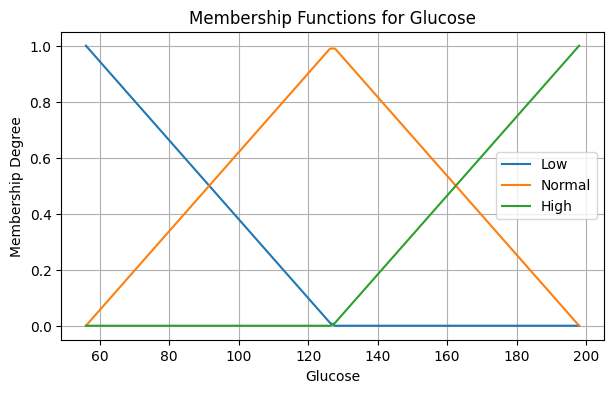

In [ ]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# Generate universe of discourse for Glucose
glucose_range = np.linspace(df_cleaned['Glucose'].min(), df_cleaned['Glucose'].max(), 100)

# Define membership functions: low, normal, high
glucose_low = fuzz.trimf(glucose_range, [glucose_range.min(), glucose_range.min(), glucose_range.mean()])
glucose_normal = fuzz.trimf(glucose_range, [glucose_range.min(), glucose_range.mean(), glucose_range.max()])
glucose_high = fuzz.trimf(glucose_range, [glucose_range.mean(), glucose_range.max(), glucose_range.max()])

# Plot the membership functions
plt.figure(figsize=(7, 4))
plt.plot(glucose_range, glucose_low, label='Low')
plt.plot(glucose_range, glucose_normal, label='Normal')
plt.plot(glucose_range, glucose_high, label='High')
plt.title('Membership Functions for Glucose')
plt.xlabel('Glucose')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True)
plt.show()


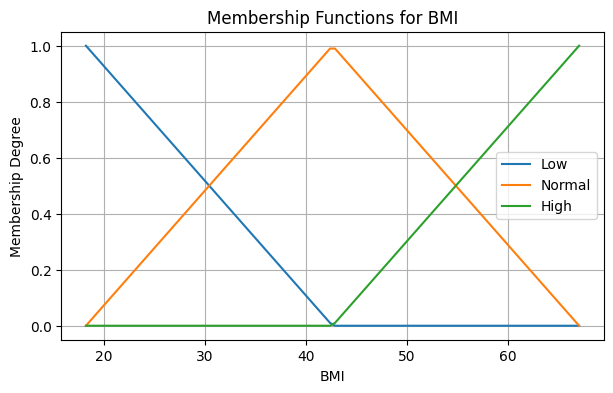

In [ ]:
# Create a range for BMI values from min to max
bmi_range = np.linspace(df_cleaned['BMI'].min(), df_cleaned['BMI'].max(), 100)

# Define fuzzy membership functions for BMI
bmi_low = fuzz.trimf(bmi_range, [bmi_range.min(), bmi_range.min(), bmi_range.mean()])
bmi_normal = fuzz.trimf(bmi_range, [bmi_range.min(), bmi_range.mean(), bmi_range.max()])
bmi_high = fuzz.trimf(bmi_range, [bmi_range.mean(), bmi_range.max(), bmi_range.max()])

# Plot the membership functions
plt.figure(figsize=(7, 4))
plt.plot(bmi_range, bmi_low, label='Low')
plt.plot(bmi_range, bmi_normal, label='Normal')
plt.plot(bmi_range, bmi_high, label='High')
plt.title('Membership Functions for BMI')
plt.xlabel('BMI')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True)
plt.show()


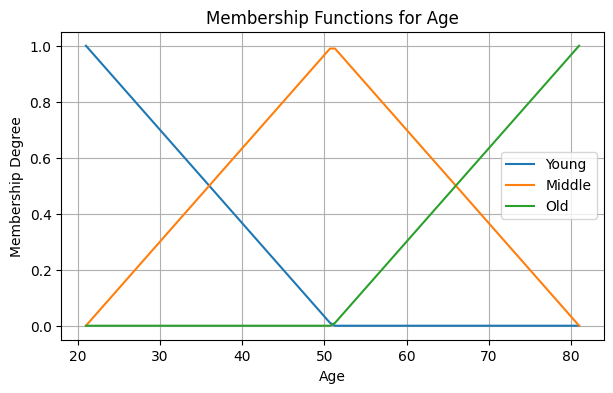

In [ ]:
# Create a range for Age from min to max
age_range = np.linspace(df_cleaned['Age'].min(), df_cleaned['Age'].max(), 100)

# Define fuzzy membership functions for Age
age_young = fuzz.trimf(age_range, [age_range.min(), age_range.min(), age_range.mean()])
age_middle = fuzz.trimf(age_range, [age_range.min(), age_range.mean(), age_range.max()])
age_old = fuzz.trimf(age_range, [age_range.mean(), age_range.max(), age_range.max()])

# Plot the membership functions
plt.figure(figsize=(7, 4))
plt.plot(age_range, age_young, label='Young')
plt.plot(age_range, age_middle, label='Middle')
plt.plot(age_range, age_old, label='Old')
plt.title('Membership Functions for Age')
plt.xlabel('Age')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True)
plt.show()


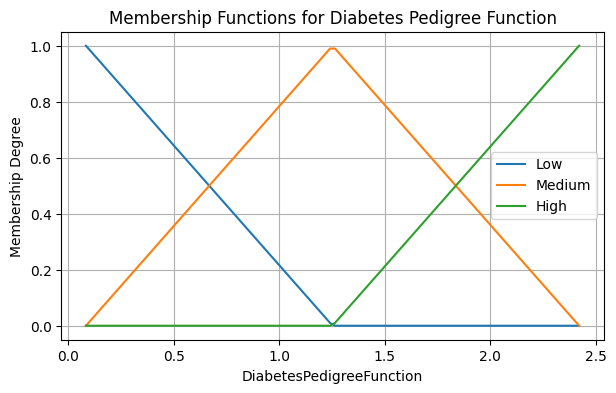

In [ ]:
# Create range for DiabetesPedigreeFunction
dpf_range = np.linspace(df_cleaned['DiabetesPedigreeFunction'].min(), df_cleaned['DiabetesPedigreeFunction'].max(), 100)

# Define fuzzy membership functions
dpf_low = fuzz.trimf(dpf_range, [dpf_range.min(), dpf_range.min(), dpf_range.mean()])
dpf_medium = fuzz.trimf(dpf_range, [dpf_range.min(), dpf_range.mean(), dpf_range.max()])
dpf_high = fuzz.trimf(dpf_range, [dpf_range.mean(), dpf_range.max(), dpf_range.max()])

# Plot the membership functions
plt.figure(figsize=(7, 4))
plt.plot(dpf_range, dpf_low, label='Low')
plt.plot(dpf_range, dpf_medium, label='Medium')
plt.plot(dpf_range, dpf_high, label='High')
plt.title('Membership Functions for Diabetes Pedigree Function')
plt.xlabel('DiabetesPedigreeFunction')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True)
plt.show()


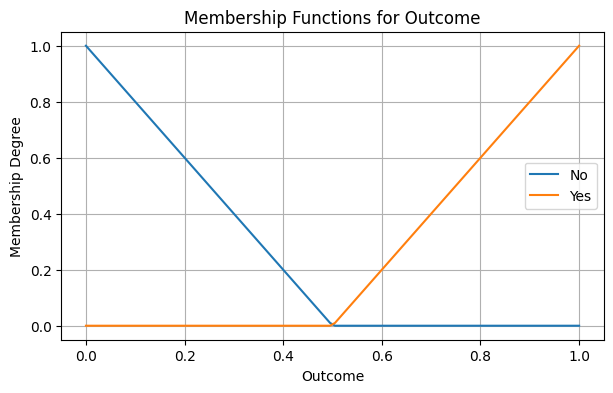

In [ ]:
# Create range for Outcome (even though it's binary, we define fuzzy sets)
outcome_range = np.linspace(0, 1, 100)

# Define fuzzy membership functions
outcome_no = fuzz.trimf(outcome_range, [0, 0, 0.5])
outcome_yes = fuzz.trimf(outcome_range, [0.5, 1, 1])

# Plot the membership functions
plt.figure(figsize=(7, 4))
plt.plot(outcome_range, outcome_no, label='No')
plt.plot(outcome_range, outcome_yes, label='Yes')
plt.title('Membership Functions for Outcome')
plt.xlabel('Outcome')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True)
plt.show()


# **ANFIS Model**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Split the data into input (X) and output (Y)
X = df_cleaned[['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']].values
Y = df_cleaned['Outcome'].values

# Normalize input features to [0, 1] for better ANFIS training
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

# Check shapes of each set
print("Train X shape:", X_train.shape)
print("Train Y shape:", Y_train.shape)
print("Test X shape:", X_test.shape)
print("Test Y shape:", Y_test.shape)


Train X shape: (313, 4)
Train Y shape: (313,)
Test X shape: (79, 4)
Test Y shape: (79,)


In [ ]:
# Simple triangular membership function
def triangular(x, a, b, c):
    return np.maximum(np.minimum((x - a) / (b - a + 1e-6), (c - x) / (c - b + 1e-6)), 0)


In [ ]:
# Define membership function parameters for each feature (normalized in [0,1])
mf_params = {
    'Glucose':   [(0.0, 0.0, 0.5), (0.25, 0.5, 0.75), (0.5, 1.0, 1.0)],
    'BMI':       [(0.0, 0.0, 0.5), (0.25, 0.5, 0.75), (0.5, 1.0, 1.0)],
    'Age':       [(0.0, 0.0, 0.5), (0.25, 0.5, 0.75), (0.5, 1.0, 1.0)],
    'DPF':       [(0.0, 0.0, 0.5), (0.25, 0.5, 0.75), (0.5, 1.0, 1.0)]
}


In [ ]:
from itertools import product

# Each feature has 3 membership levels: Low, Medium, High
# Generate all possible combinations of (Low/Med/High) for 4 features
# This creates the fuzzy rule base (3^4 = 81 rules)

rules = list(product([0, 1, 2], repeat=4))

# Print first 5 rules to check
for i, rule in enumerate(rules[:5]):
    print(f"Rule {i+1}: {rule}")

print(f"\nTotal number of rules: {len(rules)}")


Rule 1: (0, 0, 0, 0)
Rule 2: (0, 0, 0, 1)
Rule 3: (0, 0, 0, 2)
Rule 4: (0, 0, 1, 0)
Rule 5: (0, 0, 1, 1)

Total number of rules: 81


In [ ]:
# Define triangular membership function again
def triangular(x, a, b, c):
    return np.maximum(np.minimum((x - a) / (b - a + 1e-6), (c - x) / (c - b + 1e-6)), 0)

# Create big feature matrix for training data
X_features = []

for sample in X_train:
    rule_outputs = []
    for rule in rules:
        degrees = []
        for i, feature in enumerate(['Glucose', 'BMI', 'Age', 'DPF']):
            a, b, c = mf_params[feature][rule[i]]
            mu = triangular(sample[i], a, b, c)
            degrees.append(mu)
        firing_strength = np.prod(degrees)
        rule_outputs.append(firing_strength)
    X_features.append(rule_outputs)

X_big = np.array(X_features)
print("X_big shape:", X_big.shape)


X_big shape: (313, 81)


In [ ]:
# Perform Least Squares training: solve for linear output parameters
# W = (X^T X)^(-1) X^T Y  → using np.linalg.lstsq for numerical stability

W, _, _, _ = np.linalg.lstsq(X_big, Y_train, rcond=None)

# Print shape and a few learned weights
print("W shape:", W.shape)
print("First 5 output weights:", W[:5])


W shape: (81,)
First 5 output weights: [ 0.04922343 -0.42655567  0.25025126 -5.66877662 17.73449519]


In [ ]:
# Create big feature matrix for test data (like training phase)
X_features_test = []

for sample in X_test:
    rule_outputs = []
    for rule in rules:
        degrees = []
        for i, feature in enumerate(['Glucose', 'BMI', 'Age', 'DPF']):
            a, b, c = mf_params[feature][rule[i]]
            mu = triangular(sample[i], a, b, c)
            degrees.append(mu)
        firing_strength = np.prod(degrees)
        rule_outputs.append(firing_strength)
    X_features_test.append(rule_outputs)

X_big_test = np.array(X_features_test)

# Predict output by linear combination of rule strengths and weights
Y_pred = np.dot(X_big_test, W)


Accuracy: 0.6835443037974683
Confusion Matrix:
 [[44  8]
 [17 10]]


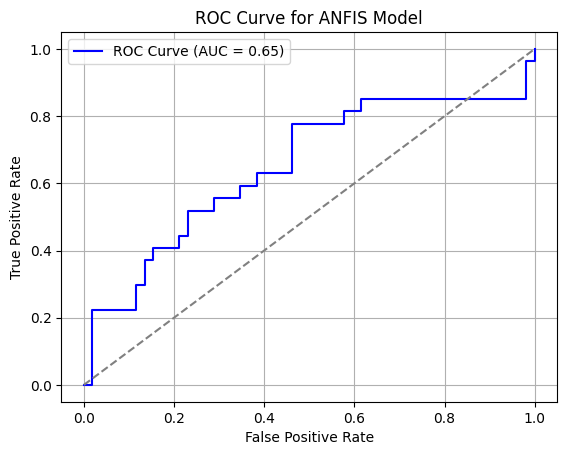

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Convert predicted probabilities to binary class (threshold = 0.5)
Y_pred_binary = (Y_pred >= 0.5).astype(int)

# Accuracy and confusion matrix
acc = accuracy_score(Y_test, Y_pred_binary)
cm = confusion_matrix(Y_test, Y_pred_binary)
print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.plot(fpr, tpr, color='blue', label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for ANFIS Model')
plt.legend()
plt.grid(True)
plt.show()
